In [102]:
import joblib
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [89]:
#Data we will be using 

data = pd.read_csv('../Datasets/pre-processedData.csv')

data.drop(columns=['Unnamed: 0'], inplace=True)
data.head(5)


print(data['is_malicious'].value_counts())

is_malicious
0    77054
1    71463
Name: count, dtype: int64


### Predicting the values from the binary classifier !

In [90]:
### Binary Classifier 

X = data.drop(columns=['is_malicious', 'Severity_Score'])
y = data['is_malicious']

### Splitting the dataset into training and testing 

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [91]:
### Testing the binary classifier model 

binary_model = joblib.load('binary_classifier.pkl')
severity_model = joblib.load('severity_model.pkl')


In [ ]:
data['Severity_Score'] = data['Severity_Score'] - 1
x_test_index = X_test.index ## To get the index of the x_test from the data
y_test_severity = data.loc[x_test_index, 'Severity_Score']  ## Gives the Severity Score of the X_test 




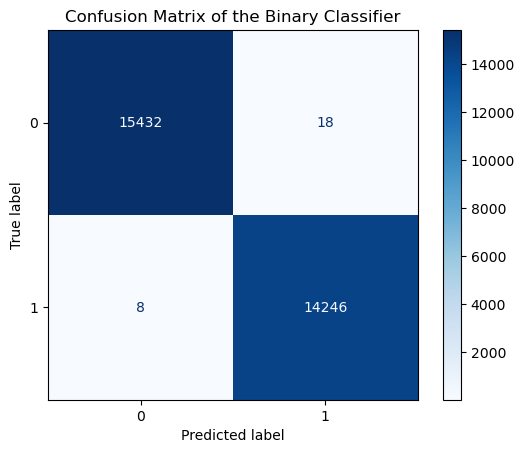

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15450
           1       1.00      1.00      1.00     14254

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



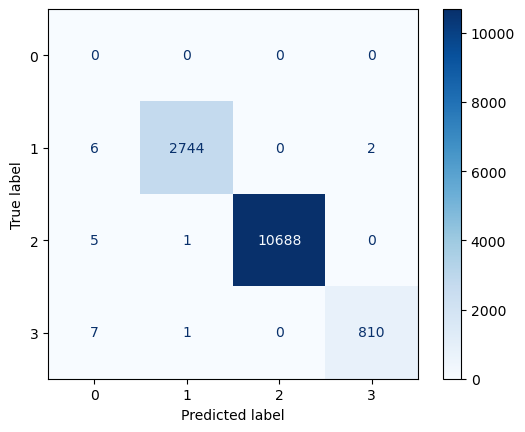

In [106]:
### Cascade analysis 
data['Severity_Score'] = data['Severity_Score']-1 
def cascade_analyis(X_test,y_test, y_test_severity):
    binary_testing_pred = binary_model.predict(X_test)

    severity_pred = np.full(len(X_test), -1)

    attack_mask = binary_testing_pred ==1 ## Only the attacks

    if attack_mask.any(): ### Just to prevent the model from empty array
        severity_pred[attack_mask] = severity_model.predict(X_test[attack_mask])

    
    ### Confusion Matrix for the binary classifier 

    evlauation_report = confusion_matrix(y_test, binary_testing_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=evlauation_report)
    display.plot(cmap = 'Blues')
    plt.title("Confusion Matrix of the Binary Classifier")
    plt.savefig('../Model Pictures/CascadeConfusionMatrixBinary.png')
    plt.show()


    ### Classification Report for the Binary Classifier
    
    severity_report = classification_report(y_test, binary_testing_pred )
    print(severity_report)

    ### Confusion Matrix for the severity classifier

    severity_evaluation_report = confusion_matrix(severity_pred[attack_mask], y_test_severity[attack_mask])
    display = ConfusionMatrixDisplay(confusion_matrix=severity_evaluation_report)
    display.plot(cmap = 'Blues')
    


cascade_analyis(X_test, y_test, y_test_severity)


In [ ]:
C